# Transportation Pricing & Cost Optimization
## 01 - Data Exploration

This notebook performs an initial exploration of the logistics transportation
pricing dataset.

The analysis focuses on:

- Product characteristics
- Shipping groups
- Product volume and weight
- Destination provinces and cities
- Transportation distances
- Data quality

### Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

### Load Data

In [4]:
file_path = "../data/raw/main.xlsx"

df_loc = pd.read_excel(file_path, sheet_name="Loc")
df_data = pd.read_excel(file_path, sheet_name="Data")

print("Data shape:", df_data.shape)
print("Location shape:", df_loc.shape)

Data shape: (13522, 9)
Location shape: (304, 6)


### Cleaning and Renaming Columns – Data 

In [5]:
print("Data columns:")
print(df_data.columns.tolist())

print("\nLocation columns:")
print(df_loc.columns.tolist())

Data columns:
['عنوان گروه ارسال کالا', 'کد گروه ارسال کالا', 'مالک کالا', 'Owner', 'کد کالا', 'نام کالا', 'گروه محصول', 'حجم', 'تناژ']

Location columns:
['استان مبدا', 'شهر مبدا', 'منطقه', 'استان مقصد', 'شهر مقصد', 'KM']


In [6]:
df_data = df_data.rename(columns={
    "عنوان گروه ارسال کالا": "shipping_group",
    "کد گروه ارسال کالا": "shipping_group_code",
    "کد کالا": "product_code",
    "نام کالا": "product_name",
    "گروه محصول": "product_group",
    "حجم": "volume_m3",
    "تناژ": "weight_ton"
})

df_loc = df_loc.rename(columns={
    "منطقه": "region",
    "استان مقصد": "dest_province",
    "شهر مقصد": "dest_city",
    "KM": "km"
})

### Select Required Fields

In [7]:
df_data = df_data[[
    "shipping_group",
    "shipping_group_code",
    "product_code",
    "product_name",
    "product_group",
    "volume_m3",
    "weight_ton"
]].copy()

df_loc = df_loc[[
    "region",
    "dest_province",
    "dest_city",
    "km"
]].copy()

### Data Types

In [8]:
df_data["volume_m3"] = pd.to_numeric(
    df_data["volume_m3"], errors="coerce"
)

df_data["weight_ton"] = pd.to_numeric(
    df_data["weight_ton"], errors="coerce"
)

df_loc["km"] = pd.to_numeric(
    df_loc["km"], errors="coerce"
)

df_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13522 entries, 0 to 13521
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   shipping_group       13522 non-null  str    
 1   shipping_group_code  13522 non-null  object 
 2   product_code         13522 non-null  str    
 3   product_name         13522 non-null  str    
 4   product_group        13522 non-null  str    
 5   volume_m3            13512 non-null  float64
 6   weight_ton           13512 non-null  float64
dtypes: float64(2), object(1), str(4)
memory usage: 739.6+ KB


### Missing Values

In [9]:
missing_data = (
    df_data.isna()
    .sum()
    .sort_values(ascending=False)
)
missing_data


weight_ton             10
volume_m3              10
shipping_group          0
product_code            0
shipping_group_code     0
product_group           0
product_name            0
dtype: int64

### For Locations

In [10]:
df_loc.isna().sum().sort_values(ascending=False)

region           0
dest_province    0
dest_city        0
km               0
dtype: int64

### Duplicate Analysis

In [11]:
print("Duplicate product rows:", df_data.duplicated().sum())
print("Duplicate location rows:", df_loc.duplicated().sum())

Duplicate product rows: 148
Duplicate location rows: 0


### Basic Business Statistics

In [12]:
print("Number of product records:", len(df_data))

print(
    "Number of unique products:",
    df_data["product_code"].nunique()
)

print(
    "Number of shipping groups:",
    df_data["shipping_group_code"].nunique()
)

print(
    "Number of product groups:",
    df_data["product_group"].nunique()
)

print(
    "Number of provinces:",
    df_loc["dest_province"].nunique()
)

print(
    "Number of cities:",
    df_loc["dest_city"].nunique()
)

Number of product records: 13522
Number of unique products: 12669
Number of shipping groups: 141
Number of product groups: 133
Number of provinces: 29
Number of cities: 303


### Product Statistics

In [13]:
df_data[[
    "volume_m3",
    "weight_ton"
]].describe()

,volume_m3,weight_ton
count,13512.000000,13512.000000
mean,0.721317,0.027206
std,35.550041,0.107543
min,0.000001,0.000000
25%,0.056380,0.000000
50%,0.175667,0.010600
75%,0.422280,0.041500
max,4128.826000,11.000000


### Shipping Group Analysis

In [14]:
group_summary = (
    df_data
    .groupby(
        ["shipping_group", "shipping_group_code"],
        as_index=False
    )
    .agg(
        products=("product_code", "nunique"),
        avg_volume_m3=("volume_m3", "mean"),
        median_volume_m3=("volume_m3", "median"),
        avg_weight_ton=("weight_ton", "mean"),
        median_weight_ton=("weight_ton", "median")
    )
)

group_summary

,shipping_group,shipping_group_code,products,avg_volume_m3,median_volume_m3,avg_weight_ton,median_weight_ton
0,"60 , 50 , 40 GSS0",241128,2,3.530992,3.530992,0.042500,0.04250
1,9000 IN & OD,241101,53,0.149378,0.131208,0.013600,0.01200
2,AV Vid & Aud,241011,137,0.155946,0.112000,0.006712,0.00000
3,AV Vid & Aud - GCH,261605,1,NaN,NaN,NaN,NaN
4,FDP Table,241015,208,0.387358,0.369546,0.005409,0.00000
...,...,...,...,...,...,...,...
136,کمپرسور یخچال Accessories,2005,45,0.013423,0.001500,0.003905,0.00032
137,کمپرسور یخچال GITA (38),2006,3,0.009413,0.009120,0.004993,0.00514
138,کمپرسور یخچال Siberia,2002,28,0.012069,0.012470,0.011601,0.01275
139,کمپرسور یخچال مدل LG,2001,12,0.009453,0.008190,0.007355,0.00784


### Province Analysis

In [15]:
province_summary = (
    df_loc
    .groupby(["dest_province", "region"], as_index=False)
    .agg(
        cities=("dest_city", "nunique"),
        median_km=("km", "median"),
        min_km=("km", "min"),
        max_km=("km", "max")
    )
)

province_summary.head()

,dest_province,region,cities,median_km,min_km,max_km
0,آذربایجان شرقی,غرب,21,696.0,512,807
1,آذربایجان غربی,غرب,14,803.5,607,925
2,اردبیل,غرب,16,698.0,580,833
3,اصفهان,مرکز,37,430.0,220,655
4,ایلام,غرب,8,644.0,605,750


### Volume Distribution

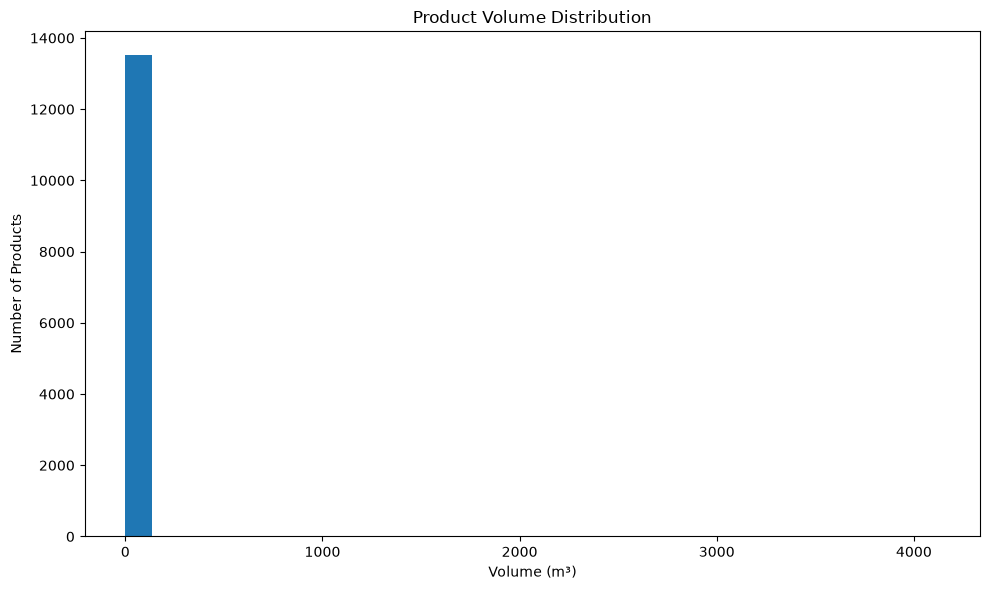

In [24]:
plt.figure(figsize=(10, 6))

plt.hist(
    df_data["volume_m3"].dropna(),
    bins=30
)

plt.title("Product Volume Distribution")
plt.xlabel("Volume (m³)")
plt.ylabel("Number of Products")

plt.tight_layout()

plt.savefig(
    "../results/figures/product_volume_distribution.png",
    dpi=300
)

plt.show()

### Weight Distribution

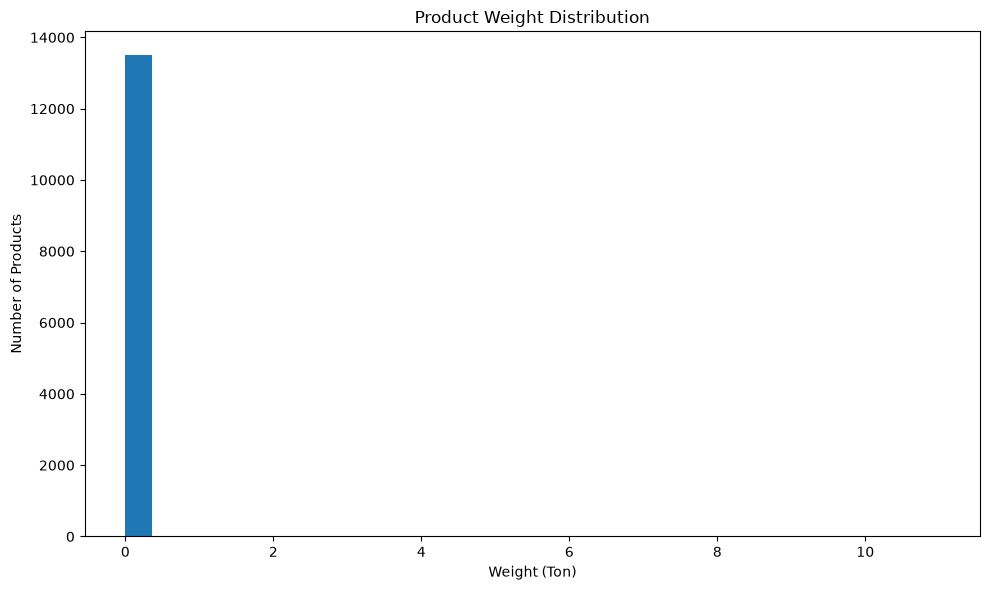

In [17]:
plt.figure(figsize=(10, 6))

plt.hist(
    df_data["weight_ton"].dropna(),
    bins=30
)

plt.title("Product Weight Distribution")
plt.xlabel("Weight (Ton)")
plt.ylabel("Number of Products")

plt.tight_layout()

plt.savefig(
    "../results/figures/product_weight_distribution.png",
    dpi=300
)

plt.show()

## Key Observations

The initial exploration provides the following observations:

- The dataset contains product-level transportation characteristics.
- Products are categorized into shipping groups.
- Product volume and weight are the main inputs for vehicle capacity analysis.
- Destination information is available at province and city levels.
- Transportation distance is available for destination analysis.
- Data quality checks are required before applying the pricing methodology.